In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from scipy.stats import gaussian_kde
from scipy.spatial import Delaunay
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from scipy.stats import gaussian_kde
from scipy.spatial import cKDTree
from matplotlib.lines import Line2D
import matplotlib.cm as cm


In [ ]:
def assign_rd_random_band(variable_1_simulated_col, variable_2_simulated_col, variable_3_simulated_col,
                          samples_xy, rp_target, df, rp_field,
                          k_neighbors=30, rel_band=0.20, rng=None):
    """
    Assigns river discharge (RD) values to bivariate samples (e.g., NTR–RF pairs)
    by randomly selecting RD values from historical/simulated data within a
    specified return-period band.

    Parameters
    ----------
    variable_1_simulated_col : str
        Column name of the first simulated variable (e.g., NTR).

    variable_2_simulated_col : str
        Column name of the second simulated variable (e.g., RF).

    variable_3_simulated_col : str
        Column name of the third variable to assign (e.g., RD).

    samples_xy : array-like (n_samples, 2)
        Coordinates of samples in the bivariate space (variable 1 vs variable 2),
        typically representing points along isolines.

    rp_target : float
        Target return period (years) for which RD values should be assigned.

    df : pandas.DataFrame
        Dataset containing historical or simulated joint samples of all variables
        (e.g., NTR, RF, RD) along with their associated return periods.

    rp_field : str
        Column name in `df` representing the return period of each sample.

    k_neighbors : int, optional (default=30)
        Number of nearest neighbors used when selecting candidate RD values.

    rel_band : float, optional (default=0.20)
        Relative tolerance around the target return period used to define
        the selection band (e.g., ±20%).

    rng : numpy.random.Generator, optional
        Random number generator for reproducibility.

    Returns
    -------
    assigned_rd : array-like
        Array of RD values assigned to each (variable 1, variable 2) sample.

    Notes
    -----
    The function selects candidate samples whose return periods fall within a
    specified band around the target return period:

        RP ∈ [rp_target * (1 - rel_band), rp_target * (1 + rel_band)]

    If too few samples are found:
        1. The band is expanded (e.g., to ±35%).
        2. If still insufficient, the full dataset is used as a fallback.

    RD values are then randomly sampled from nearby points in the joint space,
    preserving the statistical dependence between variables.

    Physical Interpretation
    -----------------------
    This approach ensures that RD values assigned to NTR–RF pairs are consistent
    with the joint distribution of all variables at a given return period,
    while still allowing stochastic variability.

    """
    if rng is None:
        rng = np.random.default_rng()

    # 1) band around the target RP
    rp_low, rp_high = rp_target * (1 - rel_band), rp_target * (1 + rel_band)
    mask = (df[rp_field] >= rp_low) & (df[rp_field] <= rp_high)

    # If too few, relax once
    if mask.sum() < 50:
        rel_band2 = max(rel_band, 0.35)
        rp_low, rp_high = rp_target * (1 - rel_band2), rp_target * (1 + rel_band2)
        mask = (df[rp_field] >= rp_low) & (df[rp_field] <= rp_high)

    # If still too few, fall back to full df (last resort)
    if mask.sum() == 0:
        mask = np.ones(len(df), dtype=bool)

    X_band = df.loc[mask, [variable_1_simulated_col, variable_2_simulated_col]].to_numpy()
    RD_band = df.loc[mask, variable_3_simulated_col].to_numpy()

    # 2) KD-tree within the band
    if len(X_band) < 2:
        # degenerate fallback: random choice from RD_band
        return rng.choice(RD_band, size=samples_xy.shape[0], replace=True)

    from scipy.spatial import cKDTree
    tree_b = cKDTree(X_band)
    k = min(k_neighbors, len(X_band))
    eps = 1e-9

    # 3) For each vertex: draw ONE neighbor by distance-weighted sampling
    dists, idxs = tree_b.query(samples_xy, k=k)
    if np.ndim(dists) == 1:
        dists = dists[:, None]
        idxs  = idxs[:, None]

    out = np.empty(samples_xy.shape[0])
    for i in range(samples_xy.shape[0]):
        di = dists[i] + eps
        wi = 1.0 / di
        wi /= wi.sum()
        pick = rng.choice(idxs[i], p=wi)  # pick ONE neighbor at random
        out[i] = RD_band[pick]
    return out

In [ ]:
def get_samples_on_isolines_and_plot(
    output_data_path,
    output_plot_path=None,
    variable_1_simulated_col="Sim_NTR",
    variable_2_simulated_col="Sim_RF",
    variable_3_simulated_col="Sim_RD",
    variable_1_input_path=None,
    variable_2_input_path=None,
    variable_3_input_path=None,
    density_col="Density",
    rp_col=None,
    rp_vals=[1, 2, 5, 10, 20, 50, 100],
    number_of_events_per_year=5,
    variable_1_label="NTR (m)",
    variable_2_label="RF (mm)",
    variable_3_label="RD (m³/s)",
    save_csv=True,
    save_plot=False,
    show_plot=True
):
    
    """
    Generates samples along return-period isolines in a bivariate space (e.g., NTR–RF),
    assigns a third variable (e.g., RD), and optionally saves and visualizes the results.

    Parameters
    ----------
    output_data_path : str
        Directory where generated sample data will be saved.

    output_plot_path : str, optional
        Path to save the generated plot.

    variable_1_simulated_col : str, optional (default="Sim_NTR")
        Column name for simulated values of the first variable (e.g., NTR).

    variable_2_simulated_col : str, optional (default="Sim_RF")
        Column name for simulated values of the second variable (e.g., RF).

    variable_3_simulated_col : str, optional (default="Sim_RD")
        Column name for the third variable (e.g., RD).

    variable_1_input_path : str
        Path to dataset containing simulated values of variable 1.

    variable_2_input_path : str
        Path to dataset containing simulated values of variable 2.

    variable_3_input_path : str
        Path to dataset containing simulated values of variable 3.

    density_col : str, optional (default="Density")
        Column representing probability density or weighting of samples.

    rp_col : str, optional
        Column representing return periods. If None, it will be computed or inferred.

    rp_vals : list of float, optional
        List of return periods (years) for which isolines are generated.

    number_of_events_per_year : int, optional (default=5)
        Number of events used in the POT framework.

    variable_1_label : str, optional
        Label for the first variable (for plotting).

    variable_2_label : str, optional
        Label for the second variable (for plotting).

    variable_3_label : str, optional
        Label for the third variable.

    save_csv : bool, optional (default=True)
        Whether to save sampled isoline points to CSV files.

    save_plot : bool, optional (default=False)
        Whether to save the generated plot.

    show_plot : bool, optional (default=True)
        Whether to display the plot.

    Returns
    -------
    None

    Workflow
    --------
    1. Reads simulated datasets for all variables (NTR, RF, RD).
    2. Combines them into a joint dataset representing multivariate samples.
    3. Computes or extracts return-period information.
    4. Generates isolines corresponding to specified return periods in the
       bivariate space (variable 1 vs variable 2).
    5. Samples points along each isoline.
    6. Assigns values of the third variable (RD) using a conditional sampling
       approach (e.g., via `assign_rd_random_band()`).
    7. Saves the resulting samples and optionally visualizes them.

    Physical Interpretation
    -----------------------
    - Isolines represent combinations of variables (e.g., NTR–RF) that correspond
      to the same return period.
    - Sampling along isolines provides a range of plausible event combinations
      rather than a single design point.
    - The third variable (RD) is assigned conditionally, preserving dependence
      across all variables.

    Applications
    ------------
    - Design of compound flooding scenarios
    - Boundary condition generation for hydrodynamic models (e.g., SFINCS)
    - Probabilistic hazard assessment

    Limitations
    -----------
    - Accuracy depends on quality of simulated joint distribution.
    - Assumes isolines are well-defined and smooth.
    - Conditional sampling introduces variability in assigned third variable.
    """

    os.makedirs(output_data_path, exist_ok=True)

    # -------------------------------------------------------------------------
    # Read the same combined file as the original code
    # -------------------------------------------------------------------------
    df_variable_1 = pd.read_csv(variable_1_input_path)
    df_variable_2 = pd.read_csv(variable_2_input_path)
    df_variable_3 = pd.read_csv(variable_3_input_path)

    df = pd.concat([df_variable_1, df_variable_2, df_variable_3], axis=0, ignore_index=True)

    if rp_col is None:
        if "ReturnPeriod_bivariate" in df.columns:
            rp_field = "ReturnPeriod_bivariate"
        elif "ReturnPeriod_Bivariate" in df.columns:
            rp_field = "ReturnPeriod_Bivariate"
        else:
            raise ValueError(
                "Could not find RP column. Please provide rp_col."
            )
    else:
        rp_field = rp_col

    df = df[df[rp_field] > 0].copy()

    # -------------------------------------------------------------------------
    # Grid
    # -------------------------------------------------------------------------
    x_min = df[variable_1_simulated_col].min()
    x_max = df[variable_1_simulated_col].max()

    y_min = df[variable_2_simulated_col].min()
    y_max = df[variable_2_simulated_col].max()

    x = np.linspace(x_min, x_max, 500)
    y = np.linspace(y_min, y_max, 500)

    X, Y = np.meshgrid(x, y)

    points = df[[variable_1_simulated_col, variable_2_simulated_col]].values
    rp_vals_all = df[rp_field].values

    # -------------------------------------------------------------------------
    # Interpolate RP surface
    # -------------------------------------------------------------------------
    Z_linear = griddata(points, rp_vals_all, (X, Y), method="linear")

    x_min_ = x.min()
    x_max_ = x.max()

    y_min_ = y.min()
    y_max_ = y.max()

    def norm_xy(xv, yv):
        return np.column_stack([
            (xv - x_min_) / (x_max_ - x_min_ + 1e-12),
            (yv - y_min_) / (y_max_ - y_min_ + 1e-12)
        ])

    pts_n = norm_xy(points[:, 0], points[:, 1])
    tree = cKDTree(pts_n)

    grid_n = norm_xy(X.ravel(), Y.ravel())

    k = 6

    d_near, i_near = tree.query(grid_n, k=1)
    d_knn, i_knn = tree.query(grid_n, k=min(k, len(points)))

    if d_knn.ndim == 1:
        d_knn = d_knn[:, None]
        i_knn = i_knn[:, None]

    vals_knn = rp_vals_all[i_knn]

    w = 1.0 / (d_knn**2 + 1e-12)
    w = w / w.sum(axis=1, keepdims=True)

    Z_idw = (w * vals_knn).sum(axis=1).reshape(X.shape)

    Z_nearest = griddata(points, rp_vals_all, (X, Y), method="nearest")

    dmax = 0.30
    dblend = 0.20

    fill_mask = np.isnan(Z_linear) & (d_near.reshape(X.shape) <= dmax)

    alpha = (d_near.reshape(X.shape) - dblend) / (dmax - dblend + 1e-12)
    alpha = np.clip(alpha, 0.0, 1.0)

    Z_fill_soft = (1.0 - alpha) * Z_idw + alpha * Z_nearest

    Z_filled = Z_linear.copy()
    Z_filled[fill_mask] = Z_fill_soft[fill_mask]

    # -------------------------------------------------------------------------
    # Plot
    # -------------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(6, 4))

    MLE_points = []
    all_rd_on_lines = []
    all_isoline_data = []

    ax.scatter(
        df[variable_1_simulated_col],
        df[variable_2_simulated_col],
        s=10,
        color="gray",
        alpha=0.5,
        label="Simulated Samples"
    )

    # -------------------------------------------------------------------------
    # RP isolines
    # -------------------------------------------------------------------------
    for rp in rp_vals:

        sigma = 30

        Z_smooth = gaussian_filter(Z_filled, sigma=sigma)

        cs = ax.contour(
            X,
            Y,
            Z_smooth,
            levels=[rp],
            colors="none"
        )

        if (
            not hasattr(cs, "allsegs")
            or len(cs.allsegs) == 0
            or len(cs.allsegs[0]) == 0
        ):
            print(f"No isoline found for RP={rp}")
            continue

        ax.contour(
            X,
            Y,
            Z_smooth,
            levels=[rp],
            colors="red",
            linewidths=2.0
        )

        for seg in cs.allsegs[0]:

            v = np.asarray(seg)

            if v.shape[0] < 8:
                continue

            rd_hat = assign_rd_random_band(
                samples_xy=v,
                rp_target=rp,
                df=df,
                rp_field=rp_field,
                variable_1_simulated_col=variable_1_simulated_col,
                variable_2_simulated_col=variable_2_simulated_col,
                variable_3_simulated_col=variable_3_simulated_col,
                k_neighbors=30,
                rel_band=0.20,
                rng=np.random.default_rng(42)
            )

            isoline_data = pd.DataFrame({
                variable_1_label: v[:, 0],
                variable_2_label: v[:, 1],
                variable_3_label: rd_hat,
                "RP": rp
            })

            all_isoline_data.append(isoline_data)
            all_rd_on_lines.append(rd_hat)

            if save_csv:
                isoline_file = os.path.join(
                    output_data_path,
                    f"Synthetic_{rp}yr_Bivariate_from_Trivariate_{number_of_events_per_year}.csv"
                )

                isoline_data.to_csv(isoline_file, index=False)

            ax.scatter(
                v[:, 0],
                v[:, 1],
                c=rd_hat,
                cmap="viridis",
                s=18,
                zorder=3
            )

            # -----------------------------------------------------------------
            # Most probable event marker
            # -----------------------------------------------------------------
            if density_col in df.columns:

                df_points = df[
                    [variable_1_simulated_col, variable_2_simulated_col]
                ].values

                tree_density = cKDTree(df_points)

                d_k, i_k = tree_density.query(v, k=1)

                dens_values = df[density_col].values[i_k]

                imax = np.argmax(dens_values)
                most_probable_point = v[imax]

                ax.plot(
                    most_probable_point[0],
                    most_probable_point[1],
                    marker="*",
                    markersize=14,
                    color="hotpink",
                    markeredgecolor="black",
                    zorder=5,
                    alpha=0.6
                )

                MLE_points.append(
                    (most_probable_point[0], most_probable_point[1], rp)
                )

            # -----------------------------------------------------------------
            # RP label, same style as original
            # -----------------------------------------------------------------
            mid = len(v) // 3

            offset = max(5, len(v) // 10)

            if mid - offset < 0:
                p1 = v[0]
            else:
                p1 = v[mid - offset]

            if mid + offset >= len(v):
                p2 = v[-1]
            else:
                p2 = v[mid + offset]

            angle = np.degrees(
                np.arctan2(
                    p2[1] - p1[1],
                    p2[0] - p1[0]
                )
            )

            if 60 < abs(angle) < 120:
                angle = 30 if angle > 0 else -30

            x_text, y_text = v[mid]

            ax.text(
                x_text,
                y_text,
                f"RP={rp}",
                fontsize=9,
                color="red",
                rotation=angle,
                rotation_mode="anchor",
                ha="center",
                va="center",
                alpha=1
            )

    # -------------------------------------------------------------------------
    # Colorbar
    # -------------------------------------------------------------------------
    if len(all_rd_on_lines) > 0:
        all_rd_concat = np.concatenate(all_rd_on_lines)

        mappable = plt.cm.ScalarMappable(cmap="viridis")
        mappable.set_array(all_rd_concat)

        cbar = plt.colorbar(mappable, ax=ax, pad=0.015)
        cbar.set_label(variable_3_label, rotation=90)

    # -------------------------------------------------------------------------
    # Legend and axes
    # -------------------------------------------------------------------------
    mle_marker = Line2D(
        [0],
        [0],
        marker="*",
        color="hotpink",
        markeredgecolor="black",
        linestyle="None",
        markersize=12,
        alpha=0.6,
        label="Most Probable Event"
    )

    scatter_proxy = Line2D(
        [0],
        [0],
        marker="o",
        color="gray",
        linestyle="None",
        alpha=0.5,
        label="Simulated Samples"
    )

    ax.legend(
        handles=[mle_marker, scatter_proxy],
        loc="upper right"
    )

    ax.set_title("Bivariate RP Isolines")
    ax.set_xlabel(variable_1_label)
    ax.set_ylabel(variable_2_label)

    ax.set_xlim([x_min, x_max])
    ax.set_ylim([y_min, y_max])

    ax.grid(True)

    plt.tight_layout()

    if save_plot and output_plot_path is not None:
        plt.savefig(output_plot_path, dpi=300)

    if show_plot:
        plt.show()
    else:
        plt.close()

    if len(all_isoline_data) > 0:
        all_isoline_data_df = pd.concat(all_isoline_data, ignore_index=True)
    else:
        all_isoline_data_df = pd.DataFrame()

    mle_df = pd.DataFrame(
        MLE_points,
        columns=[variable_1_label, variable_2_label, "RP"]
    )

    return all_isoline_data_df, mle_df

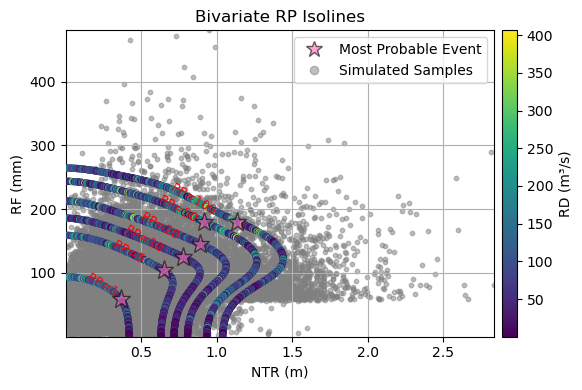

In [16]:
rp_vals = [1, 5, 10, 20, 50, 100]

df_isolines = get_samples_on_isolines_and_plot(
    variable_1_simulated_col="Sim_NTR",
    variable_2_simulated_col="Sim_RF",
    variable_3_simulated_col="Sim_RD",
    variable_1_input_path=r'C:\Users\sadaf\Desktop\Generating_Boundary_Conditions\POT_24hr_Jan26\Trivariate\OceanSprings\TimeVarying\Simulated_Backtransformed_NTR_RF_RD.csv',
    variable_2_input_path=r'C:\Users\sadaf\Desktop\Generating_Boundary_Conditions\POT_24hr_Jan26\Trivariate\OceanSprings\TimeVarying\Simulated_Backtransformed_RF_NTR_RD.csv',
    variable_3_input_path=r'C:\Users\sadaf\Desktop\Generating_Boundary_Conditions\POT_24hr_Jan26\Trivariate\OceanSprings\TimeVarying\Simulated_Backtransformed_RD_NTR_RF.csv',
    density_col="Density",
    rp_col="ReturnPeriod_Bivariate",
    number_of_events_per_year=5,
    output_plot_path=r'C:\Users\sadaf\Desktop\Generating_Boundary_Conditions\Plot.png',
    output_data_path=r'C:\Users\sadaf\Desktop\Generating_Boundary_Conditions',
    rp_vals=rp_vals
)